In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import os
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchinfo import summary

In [ ]:
# ----------------------------
# Device selection (GPU/TPU/CPU)
# ----------------------------
# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
# Check for TPU availability (using PyTorch/XLA)
elif 'TPU_ACCELERATOR_TYPE' in os.environ or 'COLAB_TPU_1vm' in os.environ:
    import torch_xla
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
else:
    # Default to CPU if no GPU or TPU is available
    device = torch.device("cpu")

# Print the selected device
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Preprocessing: scale to [-1, 1] and pad to 32x32, with augmentation
transform = transforms.Compose([
    transforms.Pad(2),  # Pad to 32x32
    transforms.RandomRotation(10),  # Data augmentation
    transforms.ToTensor(),
    lambda x: x * 2 - 1
])

In [ ]:
# Dataset and loader
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
# Reduced batch size for more stable gradient estimates
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

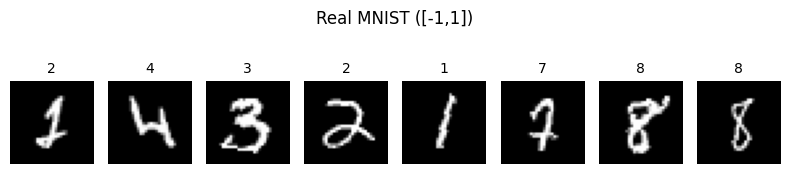

In [ ]:
# Visualize real samples
data_iter = iter(train_loader)
images, labels = next(data_iter)
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(images[i][0].cpu().numpy(), cmap='gray')
    plt.title(f"{labels[i].item()}", fontsize=10)
    plt.axis('off')
plt.suptitle("Real MNIST ([-1,1])")
plt.tight_layout()
plt.show()

In [ ]:
class ConditionalUNetScore(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        # Embedding size = bottleneck output channels
        self.class_emb = nn.Embedding(num_classes, base_ch * 8)  # matches bottleneck

        # Encoder (4 levels)
        self.enc1 = self._conv_block(in_ch, base_ch)           # 32x32
        self.enc2 = self._conv_block(base_ch, base_ch * 2)     # 16x16
        self.enc3 = self._conv_block(base_ch * 2, base_ch * 4) # 8x8
        self.enc4 = self._conv_block(base_ch * 4, base_ch * 8) # 4x4

        # Decoder (4 levels)
        self.up4 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)  # 8x8
        self.dec4 = self._conv_block(base_ch * 8, base_ch * 4)
        self.up3 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)  # 16x16
        self.dec3 = self._conv_block(base_ch * 4, base_ch * 2)
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=2, stride=2)     # 32x32
        self.dec2 = self._conv_block(base_ch * 2, base_ch)
        # Final is linear (no activation) because we are estimating a score (unbounded)
        self.final = nn.Conv2d(base_ch, in_ch, kernel_size=1)

    def _conv_block(self, in_c, out_c):
        # Simple conv block without BatchNorm or Dropout to avoid normalization issues with higher-order gradients
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, y):
        # Encoder
        e1 = self.enc1(x)                          # 32x32
        e2 = self.enc2(F.avg_pool2d(e1, 2))        # 16x16
        e3 = self.enc3(F.avg_pool2d(e2, 2))        # 8x8
        b = self.enc4(F.avg_pool2d(e3, 2))         # 4x4

        # Inject class
        emb = self.class_emb(y).view(b.shape[0], -1, 1, 1)  # (B, base_ch*8, 1, 1)
        b = b + emb

        # Decoder
        d4 = self.up4(b)                           # 8x8
        d4 = torch.cat([d4, e3], dim=1)            # 8x8 + 8x8
        d4 = self.dec4(d4)

        d3 = self.up3(d4)                          # 16x16
        d3 = torch.cat([d3, e2], dim=1)            # 16x16 + 16x16
        d3 = self.dec3(d3)

        d2 = self.up2(d3)                          # 32x32
        d2 = torch.cat([d2, e1], dim=1)            # 32x32 + 32x32
        d2 = self.dec2(d2)

        return self.final(d2)

In [ ]:
# Initialize model with slightly larger base channels to improve capacity
model = ConditionalUNetScore(in_ch=1, base_ch=32, num_classes=10).to(device)

#model = torch.compile(model)

In [ ]:
def conditional_ssm_vr_loss(score_net, x, y, n_projections=2):
    """
    Variance-reduced Sliced Score Matching loss with class conditioning.
    Uses Rademacher projections v ∈ {±1}^D and averages over n_projections to reduce variance.
    Normalizes by the number of input dimensions to keep magnitudes stable.
    """
    B, C, H, W = x.shape
    D = C * H * W
    x = x.requires_grad_(True)
    s = score_net(x, y)  # conditioned score (shape B,C,H,W)

    v_hessian_v_total = 0.0
    norm_s_sq_total = 0.0
    for _ in range(n_projections):
        # Sample Rademacher vector in {-1, +1}
        v = torch.randint(0, 2, (B, C, H, W), device=x.device, dtype=torch.float32) * 2 - 1
        # Compute v^T s (per-sample)
        v_dot_s = (v * s).view(B, -1).sum(dim=1)
        # Compute ∇_x (v^T s)  -- need create_graph=True to backprop through this gradient later
        grad_vdot_s = torch.autograd.grad(v_dot_s.sum(), x, create_graph=True)[0]
        # v^T (∇_x s) v (per-sample)
        v_hessian_v = (v * grad_vdot_s).view(B, -1).sum(dim=1)
        v_hessian_v_total += v_hessian_v
        # ||s||^2 (per-sample)
        norm_s_sq = (s ** 2).view(B, -1).sum(dim=1)
        norm_s_sq_total += norm_s_sq

    # Average over projections and normalize by dimension D to keep scale independent of image size
    v_hessian_v_avg = v_hessian_v_total / float(n_projections)
    norm_s_sq_avg = norm_s_sq_total / float(n_projections)

    loss = (v_hessian_v_avg + 0.5 * norm_s_sq_avg).mean()
    return loss

In [ ]:
def ssm_vr_loss(score_net, x, y, M=32):
    """
    Variance-Reduced Sliced Score Matching (SSM-VR)
    with Rademacher directions.

    Implements exactly:
        J(θ; x_{1:N1}, v_{1:M1})
    from the paper.
    """
    B, C, H, W = x.shape
    D = C * H * W
    x = x.requires_grad_(True)
    s = score_net(x, y)          # score: (B, C, H, W)

    total = 0.0

    for _ in range(M):
        # ---- 1. Sample Rademacher direction v ~ Unif({-1,+1}^D) ----
        v = torch.randint(0, 2, (B, C, H, W), device=x.device, dtype=torch.float32) * 2 - 1

        # ---- 2. Compute v^T s(x) ----
        v_dot_s = (v * s).sum(dim=[1,2,3])  # scalar per batch element

        # ---- 3. Compute ∇_x ( v^T s ) ----
        grad_vdot_s = torch.autograd.grad(
            v_dot_s.sum(), x,
            create_graph=True,
            retain_graph=True
        )[0]

        # ---- 4. Compute v^T ( ∇_x s ) v = v · ∇_x (v·s) ----
        directional_hvp = (v * grad_vdot_s).sum(dim=[1,2,3])

        # ---- 5. Add 1/2 ||s||^2 ----
        norm_s_sq = (s ** 2).sum(dim=[1,2,3])

        total += directional_hvp + 0.5 * norm_s_sq

    # ---- 6. Average over M projections ----
    return total.mean() / M


In [ ]:
# Quick test
x_test = torch.randn(2, 1, 32, 32, device=device)
y_test = torch.randint(0, 10, (2,), device=device)
loss_test = conditional_ssm_vr_loss(model, x_test, y_test)
print(f"Test loss: {loss_test.item():.4f}")

Test loss: 73.0441


In [ ]:
# Optimizer: switched to Adam with small LR to stabilize SSM training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
# LR scheduler to reduce LR on plateau of validation/train loss
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
# Training
epochs = 200

In [ ]:
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = conditional_ssm_vr_loss(model, x, y, n_projections=32)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Bad loss (nan/inf) at epoch {epoch+1}, batch {batch_idx}: {loss}")
            raise RuntimeError("Loss exploded to NaN/Inf — aborting training")
        loss.backward()
        # Optimizer step (no gradient clipping)
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    # Step LR scheduler on training loss (can change to validation loss if available)
    try:
        scheduler.step(avg_loss)
    except Exception as e:
        print('Scheduler step failed:', e)

Epoch 1, Batch 0, Loss: 58.7533
Epoch 1, Batch 100, Loss: -1160041.6250
Epoch 1, Batch 200, Loss: -6247127.0000
Epoch 1, Batch 300, Loss: -9292.5137
Epoch 1, Batch 400, Loss: -453.2257
Epoch 1/20 | Avg Loss: -1504034.7947
Epoch 2, Batch 0, Loss: -464.0980
Epoch 2, Batch 100, Loss: -52.1140
Epoch 2, Batch 200, Loss: -394.3693
Epoch 2, Batch 300, Loss: -95.1244
Epoch 2, Batch 400, Loss: -212.4434
Epoch 2/20 | Avg Loss: -1617.5251
Epoch 3, Batch 0, Loss: -59.3749
Epoch 3, Batch 100, Loss: -46.8186
Epoch 3, Batch 200, Loss: -205.0325
Epoch 3, Batch 300, Loss: -428.3287
Epoch 3, Batch 400, Loss: -386.4335
Epoch 3/20 | Avg Loss: -2087.9543
Epoch 4, Batch 0, Loss: -50.0541
Epoch 4, Batch 100, Loss: -130.2700
Epoch 4, Batch 200, Loss: 27.8483
Epoch 4, Batch 300, Loss: 1.3977
Epoch 4, Batch 400, Loss: -101.9498
Epoch 4/20 | Avg Loss: -1271.8441
Epoch 5, Batch 0, Loss: -31.6642
Epoch 5, Batch 100, Loss: -73.1488
Epoch 5, Batch 200, Loss: 10.4826
Epoch 5, Batch 300, Loss: 29.1471
Epoch 5, Batch 4

In [ ]:
# Save model
torch.save(model.state_dict(), "conditional_ssm_mnist.pth")
print("Model saved.")

Model saved.


In [ ]:
@torch.no_grad()
def conditional_langevin_dynamics(score_net, y, shape, n_steps=1000, eps=1e-3, device="cpu"):
    """
    Generate samples for class y.
    y: tensor of shape (B,) with class labels.
    """
    x = torch.randn(shape, device=device)
    score_net.eval()
    for _ in range(n_steps):
        x = x.requires_grad_(True)
        s = score_net(x, y)
        x = x + eps * s + torch.sqrt(torch.tensor(2 * eps)) * torch.randn_like(x)
        x = x.detach()
    return torch.clamp(x, -1, 1)

# Generate 8 samples per digit (0–9)
all_samples = []
all_labels = []
for digit in range(10):
    y = torch.full((8,), digit, device=device)
    samples = conditional_langevin_dynamics(model, y, (8, 1, 32, 32), n_steps=1000, eps=1e-3, device=device)
    all_samples.append(samples)
    all_labels.extend([digit] * 8)

# Concatenate
generated = torch.cat(all_samples, dim=0)
generated = (generated + 1) / 2  # [0,1] for plotting

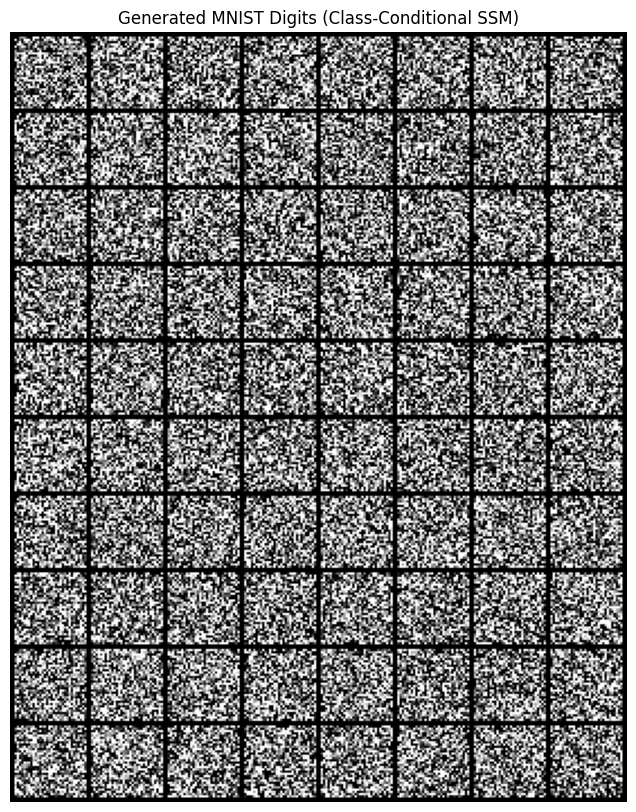

In [ ]:
# Plot
plt.figure(figsize=(10, 10))
grid = torchvision.utils.make_grid(generated, nrow=8, padding=2)
plt.imshow(grid.cpu().permute(1, 2, 0).numpy(), cmap='gray')
plt.axis('off')
plt.title("Generated MNIST Digits (Class-Conditional SSM)")
plt.savefig("conditional_ssm_samples.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Diagnostic: inspect model score outputs and sampler behavior
try:
    xb, yb = next(iter(train_loader))
except Exception as e:
    raise RuntimeError('Failed to get batch from train_loader: ' + str(e))
xb, yb = xb.to(device), yb.to(device)
model.eval()
with torch.no_grad():
    s_real = model(xb[:8], yb[:8])  # model scores on real batch
    print('Input batch stats   : min {:.4e}, max {:.4e}, mean {:.4e}, std {:.4e}'.format(xb[:8].min().item(), xb[:8].max().item(), xb[:8].mean().item(), xb[:8].std().item()))
    print('Score (real) stats  : min {:.4e}, max {:.4e}, mean {:.4e}, std {:.4e}'.format(s_real.min().item(), s_real.max().item(), s_real.mean().item(), s_real.std().item()))
    # Also evaluate model on pure gaussian noise
    noise = torch.randn_like(xb[:8])
    s_noise = model(noise, yb[:8])
    print('Noise input stats   : min {:.4e}, max {:.4e}, mean {:.4e}, std {:.4e}'.format(noise.min().item(), noise.max().item(), noise.mean().item(), noise.std().item()))
    print('Score (noise) stats : min {:.4e}, max {:.4e}, mean {:.4e}, std {:.4e}'.format(s_noise.min().item(), s_noise.max().item(), s_noise.mean().item(), s_noise.std().item()))

# Run the existing Langevin sampler for a short test (keeps the original sampler unchanged)
try:
    y_sample = torch.full((4,), 0, device=device)  # test digit 0
    samples_test = conditional_langevin_dynamics(model, y_sample, (4,1,32,32), n_steps=200, eps=1e-3, device=device)  # shorter run
    print('Sampler output stats : min {:.4e}, max {:.4e}, mean {:.4e}, std {:.4e}'.format(samples_test.min().item(), samples_test.max().item(), samples_test.mean().item(), samples_test.std().item()))
    # Convert to [0,1] for plotting
    samples_vis = (samples_test + 1) / 2.0
except Exception as e:
    print('Sampler test failed:', e)
    samples_vis = None

# Plot real batch scores and sampler outputs
import matplotlib.pyplot as plt
import torchvision
try:
    fig, axes = plt.subplots(2,2, figsize=(6,6))
    # show first 4 real images
    grid_real = torchvision.utils.make_grid((xb[:4] + 1)/2.0, nrow=4)
    axes[0,0].imshow(grid_real.cpu().permute(1,2,0).numpy(), cmap='gray')
    axes[0,0].set_title('Real images (scaled)')
    axes[0,0].axis('off')
    # show score maps (take channel-wise absolute sum for visualization)
    s_vis = s_real[:4].abs().sum(dim=1, keepdim=True)
    s_vis = (s_vis - s_vis.min()) / (s_vis.max() - s_vis.min() + 1e-8)
    grid_s = torchvision.utils.make_grid(s_vis, nrow=4)
    axes[0,1].imshow(grid_s.cpu().permute(1,2,0).numpy(), cmap='magma')
    axes[0,1].set_title('Score magnitude (scaled)')
    axes[0,1].axis('off')
    # sampler outputs (if available)
    if samples_vis is not None:
        grid_gen = torchvision.utils.make_grid(samples_vis, nrow=4)
        axes[1,0].imshow(grid_gen.cpu().permute(1,2,0).numpy(), cmap='gray')
        axes[1,0].set_title('Sampler outputs (scaled)')
        axes[1,0].axis('off')
    else:
        axes[1,0].text(0.5,0.5,'No samples', ha='center')
        axes[1,0].axis('off')
    # show score stats text
    axes[1,1].axis('off')
    stats_text = f"s_real mean={s_real.mean().item():.4e}\ns_real std={s_real.std().item():.4e}\ns_noise mean={s_noise.mean().item():.4e}\ns_noise std={s_noise.std().item():.4e}\nsamples min={samples_test.min().item() if 'samples_test' in locals() else float('nan'):.4e}\nsamples max={samples_test.max().item() if 'samples_test' in locals() else float('nan'):.4e}"
    axes[1,1].text(0.01, 0.5, stats_text, fontsize=10, va='center')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Plotting failed:', e)